# Работа с SQL базой в Python

База данных sakila - учебна база от разработчиков mysql. Она описывает работу вымышленного магазина проката DVD-дисков. Структура базы описана в файле `sakila-en.a4.pdf`.

Подключение к базе выполняется следующим образом.

In [1]:
import mysql.connector

user='admin'
password='admin'
host='mysql'
port=3306
database='sakila'

try:
    cnx = mysql.connector.connect(
        user=user, password=password,
        host=host, port=port, database=database)
    print(f"""Подключение установлено:
хост: {cnx.server_host}
порт: {cnx.server_port}
пользователь: {cnx.user}""")
except mysql.connector.Error as e:
    print(f"Ошибка подключения к серверу:\n{e}")

cursor = cnx.cursor()    

Подключение установлено:
хост: mysql
порт: 3306
пользователь: admin


## Задание 1
Используя таблицы `rental` и `customer`, напишите запрос, который будет подсчитывать, сколько заказов сделал каждый из клиентов.

Пример выполнения задания:

In [2]:
qu = """
SELECT c.first_name, c.last_name, COUNT(*) AS cnt
FROM rental r
JOIN customer c ON r.customer_id = c.customer_id
GROUP BY c.customer_id
ORDER BY cnt desc
LIMIT 10
"""
cursor.execute(qu)
rows = cursor.fetchall()   
for row in rows:
    print(row)

('ELEANOR', 'HUNT', 46)
('KARL', 'SEAL', 45)
('CLARA', 'SHAW', 42)
('MARCIA', 'DEAN', 42)
('TAMMY', 'SANDERS', 41)
('SUE', 'PETERS', 40)
('WESLEY', 'BULL', 40)
('MARION', 'SNYDER', 39)
('RHONDA', 'KENNEDY', 39)
('TIM', 'CARY', 39)


После выполнения этого запроса объект `cursor` предоставляет генератор, по которому можно итерировать в цикле `for`. Так как этоо генератор, то итерировать можно только один раз. Чтобы выполнить итерации повторно, нужно снова выполнить запрос.

In [3]:
cursor.execute(qu)
for rec in cursor:
    print(f"{rec}")

('ELEANOR', 'HUNT', 46)
('KARL', 'SEAL', 45)
('CLARA', 'SHAW', 42)
('MARCIA', 'DEAN', 42)
('TAMMY', 'SANDERS', 41)
('SUE', 'PETERS', 40)
('WESLEY', 'BULL', 40)
('MARION', 'SNYDER', 39)
('RHONDA', 'KENNEDY', 39)
('TIM', 'CARY', 39)


При помощи метода `.fetchall` можно получить результаты запроса в виде списка. 

In [4]:
cursor.execute(qu)
data = cursor.fetchall()
print(data)

[('ELEANOR', 'HUNT', 46), ('KARL', 'SEAL', 45), ('CLARA', 'SHAW', 42), ('MARCIA', 'DEAN', 42), ('TAMMY', 'SANDERS', 41), ('SUE', 'PETERS', 40), ('WESLEY', 'BULL', 40), ('MARION', 'SNYDER', 39), ('RHONDA', 'KENNEDY', 39), ('TIM', 'CARY', 39)]


Выполнить запрос, привести имена и фамилии к нижнему регистру кроме перовой буквы, собрать их вместе и построить столбцовую диаграмму заказов первых 10 самых "преданных" клиентов.

In [5]:
cursor.execute(qu)
names = []
cnts = []
for first_name, last_name, cnt in cursor:
    names.append(f"{first_name[0] + first_name[1:].lower()} {last_name[0] + last_name[1:].lower()}")
    cnts.append(cnt)

print(names)
print(cnts)

['Eleanor Hunt', 'Karl Seal', 'Clara Shaw', 'Marcia Dean', 'Tammy Sanders', 'Sue Peters', 'Wesley Bull', 'Marion Snyder', 'Rhonda Kennedy', 'Tim Cary']
[46, 45, 42, 42, 41, 40, 40, 39, 39, 39]


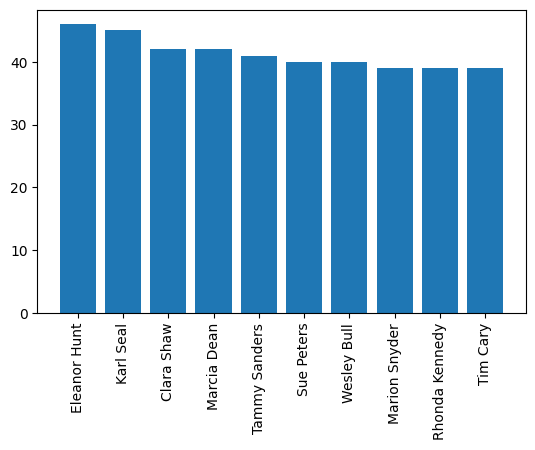

In [6]:
import matplotlib.pyplot as plt
cm = 1.0 / 2.54

fig, ax = plt.subplots(figsize=(16*cm, 10*cm))
ax.bar(names, cnts)
ax.tick_params(axis='x', labelrotation=90)

## Задание 2

Постройте запрос, возвращающий количество фильмов, в которых снимался каждый актёр из числа тех, что внесены в базу. Для десяти наиболее популярных актёров постройте столбчатую диаграмму с горизонтальными столбцам: по оси абсцисс отложите имена и фамилии актёров, по оси ординат - число фильмов.

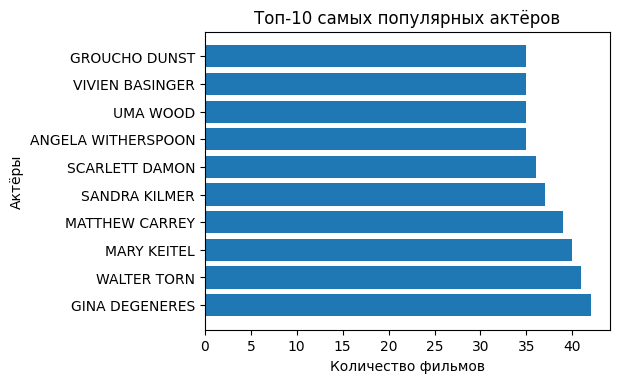

In [7]:
requst = """
SELECT
    COUNT(fa.actor_id) as count_film,
    a.first_name,
    a.last_name
FROM actor a
JOIN film_actor fa on a.actor_id = fa.actor_id
GROUP BY a.actor_id
ORDER BY count_film desc
LIMIT 10
"""

cursor.execute(requst)
data = cursor.fetchall()

cnts = [row[0] for row in data]
names = [f"{row[1]} {row[2]}" for row in data]

cm = 1.0 / 2.54
fig, ax = plt.subplots(figsize=(16*cm, 10*cm))

ax.barh(names, cnts)

ax.set_xlabel("Количество фильмов")
ax.set_ylabel("Актёры")
ax.set_title("Топ-10 самых популярных актёров")
plt.tight_layout()
plt.show()

Горизонтальная, но имена по абцисс невозможно


## Задание 3

Постройте запрос, который подсчитывает количество копий (дисков) каждого из фильмов. Используя Python, получите список фильмов для которых имеется больше всего копий.

In [8]:
requst = """
SELECT f.title,
       COUNT(i.inventory_id) AS copies
FROM film f
JOIN inventory i ON f.film_id = i.film_id
GROUP BY f.film_id, f.title
ORDER BY copies DESC
"""

cursor.execute(requst)
data = cursor.fetchall()

max_copies = data[0][1]

most_copied_films = [title for title, copies in data if copies == max_copies]

print("Максимальное количество копий:", max_copies)
print("Фильмы с максимальным числом копий:", most_copied_films)

Максимальное количество копий: 8
Фильмы с максимальным числом копий: ['ACADEMY DINOSAUR', 'APACHE DIVINE', 'BEVERLY OUTLAW', 'BINGO TALENTED', 'BOOGIE AMELIE', 'BOUND CHEAPER', 'BUCKET BROTHERHOOD', 'BUTTERFLY CHOCOLAT', 'CAT CONEHEADS', 'CONFIDENTIAL INTERVIEW', 'CROSSROADS CASUALTIES', 'CUPBOARD SINNERS', 'CURTAIN VIDEOTAPE', 'DANCING FEVER', 'DEER VIRGINIAN', 'DINOSAUR SECRETARY', 'DOGMA FAMILY', 'DYNAMITE TARZAN', 'EXPENDABLE STALLION', 'FAMILY SWEET', 'FORWARD TEMPLE', 'FROST HEAD', 'GARDEN ISLAND', 'GIANT TROOPERS', 'GILMORE BOILED', 'GLEAMING JAWBREAKER', 'GOODFELLAS SALUTE', 'GREATEST NORTH', 'GRIT CLOCKWORK', 'HARRY IDAHO', 'HEAVYWEIGHTS BEAST', 'HOBBIT ALIEN', 'HORROR REIGN', 'HUSTLER PARTY', 'INNOCENT USUAL', 'INVASION CYCLONE', 'JUGGLER HARDLY', 'KISS GLORY', 'LOATHING LEGALLY', 'LOSE INCH', 'MARRIED GO', 'METROPOLIS COMA', 'MOCKINGBIRD HOLLYWOOD', 'MOON BUNCH', 'MUSCLE BRIGHT', 'NETWORK PEAK', 'OPERATION OPERATION', 'PITY BOUND', 'PRIMARY GLASS', 'PULP BEVERLY', 'RIDGEMONT

## Задание 4

Постройте запрос, который строит список названий фильмов, начинающихся на 'Z', и адресов по которым хранятся соответствующие диски.

In [9]:
requst = """
SELECT f.title,
       a.address
FROM film f
JOIN inventory i ON f.film_id = i.film_id
JOIN store s ON i.store_id = s.store_id
JOIN address a ON s.address_id = a.address_id
WHERE f.title LIKE 'Z%'
ORDER BY f.title, a.address;
"""

cursor.execute(requst)
data = cursor.fetchall()

for title, address in data:
    print(f"{title}:  {address}")

ZHIVAGO CORE:  28 MySQL Boulevard
ZHIVAGO CORE:  28 MySQL Boulevard
ZOOLANDER FICTION:  28 MySQL Boulevard
ZOOLANDER FICTION:  28 MySQL Boulevard
ZOOLANDER FICTION:  28 MySQL Boulevard
ZOOLANDER FICTION:  47 MySakila Drive
ZOOLANDER FICTION:  47 MySakila Drive
ZORRO ARK:  28 MySQL Boulevard
ZORRO ARK:  28 MySQL Boulevard
ZORRO ARK:  28 MySQL Boulevard
ZORRO ARK:  28 MySQL Boulevard
ZORRO ARK:  47 MySakila Drive
ZORRO ARK:  47 MySakila Drive
ZORRO ARK:  47 MySakila Drive
ZORRO ARK:  47 MySakila Drive


## Задание 5

Постройте и выполните запрос, который выводит адреса хранилищ дисков и количество дисков в каждом из них.

In [10]:
requst = """
SELECT a.address,
       COUNT(i.inventory_id) AS num_disks
FROM inventory i
JOIN store s ON i.store_id = s.store_id
JOIN address a ON s.address_id = a.address_id
GROUP BY a.address
ORDER BY num_disks DESC;
"""

cursor.execute(requst)
data = cursor.fetchall() 

for address, num_disks in data:
    print(f"{address}  :  {num_disks} дисков")


28 MySQL Boulevard  :  2311 дисков
47 MySakila Drive  :  2270 дисков


## Задание 6

Постройте и выполните запрос, который подсчитывает количество взятых в прокат дисков по месяцам. Постройте на основе его результаиа столбчатую диаграмму, в которой по оси абсцисс были бы отложены месяцы, от января до декабря включительно, а по оси ординат — количество взятых дисков. Вероятно, потребуется использовать модуль calendar.

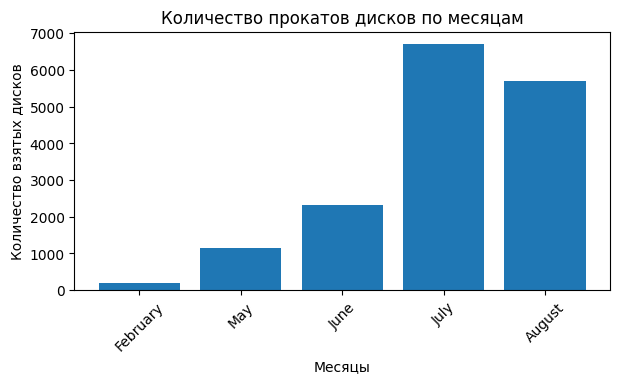

In [11]:
import calendar

requst = """
SELECT EXTRACT(MONTH FROM rental_date) AS month,
       COUNT(rental_id) AS num_rentals
FROM rental
GROUP BY month
ORDER BY month;
"""
cursor.execute(requst)
data = cursor.fetchall()

months_numbers = [int(row[0]) for row in data]
num_rentals = [row[1] for row in data] 

months_names = [calendar.month_name[m] for m in months_numbers]

cm = 1.0 / 2.54
fig, ax = plt.subplots(figsize=(16*cm, 10*cm))
ax.bar(months_names, num_rentals)
ax.set_xlabel("Месяцы")
ax.set_ylabel("Количество взятых дисков")
ax.set_title("Количество прокатов дисков по месяцам")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()